Student Performance **Prediction**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/student_performance.csv")

In [3]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [4]:
df.shape

(1000000, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [6]:
X = df[[
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]]

y = df["total_score"]

In [7]:
X.head()

,weekly_self_study_hours,attendance_percentage,class_participation
0,18.5,95.6,3.8
1,14.0,80.0,2.5
2,19.5,86.3,5.3
3,25.7,70.2,7.0
4,13.4,81.9,6.9


In [8]:
y.head()

,total_score
0,97.9
1,83.9
2,100.0
3,100.0
4,92.0


In [9]:
X.shape

(1000000, 3)

In [10]:
y.shape

(1000000,)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800000, 3)
(200000, 3)
(800000,)
(200000,)


In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

LinearRegression()

In [18]:
print("Model trained successfully!")

Model trained successfully!


In [19]:
y_pred = model.predict(X_test)

In [20]:
y_pred[:10]

array([64.05954219, 88.03598894, 72.79127762, 84.24282459, 58.60876743,
       63.88168567, 64.42332547, 64.60985945, 85.14087917, 79.67978296])

In [21]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
0,53.9,64.059542
1,77.3,88.035989
2,75.0,72.791278
3,85.7,84.242825
4,30.8,58.608767
5,62.3,63.881686
6,74.0,64.423325
7,68.9,64.609859
8,83.7,85.140879
9,95.5,79.679783


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 7.161333476729997


In [25]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 80.9352286743695


In [26]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 8.996400873369833


In [27]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.6600425865640975


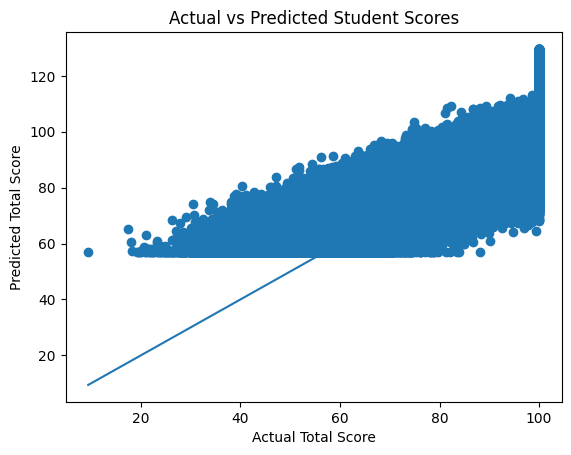

In [30]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title("Actual vs Predicted Student Scores")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [31]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 1.81682003e+00  4.01750743e-04 -2.75562094e-03]
Intercept: 56.95355744476303


In [32]:
df[[
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score"
]].corr()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
weekly_self_study_hours,1.000000,-0.001008,0.001244,0.812241
attendance_percentage,-0.001008,1.000000,-0.000043,-0.001014
class_participation,0.001244,-0.000043,1.000000,0.000684
total_score,0.812241,-0.001014,0.000684,1.000000


In [33]:
results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

results.head(10)

,Actual Score,Predicted Score
0,53.9,64.059542
1,77.3,88.035989
2,75.0,72.791278
3,85.7,84.242825
4,30.8,58.608767
5,62.3,63.881686
6,74.0,64.423325
7,68.9,64.609859
8,83.7,85.140879
9,95.5,79.679783


In [34]:
results["Error"] = results["Actual Score"] - results["Predicted Score"]

results.head(10)

,Actual Score,Predicted Score,Error
0,53.9,64.059542,-10.159542
1,77.3,88.035989,-10.735989
2,75.0,72.791278,2.208722
3,85.7,84.242825,1.457175
4,30.8,58.608767,-27.808767
5,62.3,63.881686,-1.581686
6,74.0,64.423325,9.576675
7,68.9,64.609859,4.290141
8,83.7,85.140879,-1.440879
9,95.5,79.679783,15.820217


In [35]:
results["Absolute Error"] = abs(results["Error"])

results.head(10)

,Actual Score,Predicted Score,Error,Absolute Error
0,53.9,64.059542,-10.159542,10.159542
1,77.3,88.035989,-10.735989,10.735989
2,75.0,72.791278,2.208722,2.208722
3,85.7,84.242825,1.457175,1.457175
4,30.8,58.608767,-27.808767,27.808767
5,62.3,63.881686,-1.581686,1.581686
6,74.0,64.423325,9.576675,9.576675
7,68.9,64.609859,4.290141,4.290141
8,83.7,85.140879,-1.440879,1.440879
9,95.5,79.679783,15.820217,15.820217


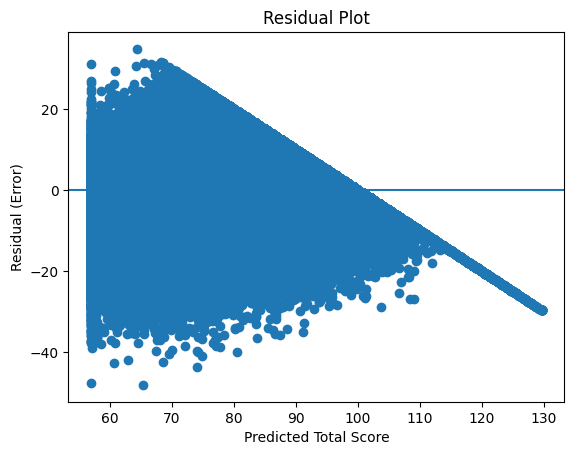

In [36]:
plt.scatter(y_pred, results["Error"])

plt.axhline(y=0)

plt.xlabel("Predicted Total Score")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot")

plt.show()